In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
base = Path.cwd()
candidates = [base, base.parent, Path("/mnt/data")]
def locate(name):
    for p in candidates:
        q = p / name
        if q.exists():
            return q
    raise FileNotFoundError(name)
details = pd.read_csv(locate("order_details(3).csv"))
timestamps = pd.read_csv(locate("order_timestamp(3).csv"))
for c in ["start_time_slot", "accept_time", "arrived_pickup_at"]:
    timestamps[c] = pd.to_datetime(timestamps[c], errors="coerce")
details["created_date"] = pd.to_datetime(details["created_date"], errors="coerce")
df = details.merge(timestamps, on="order_id", how="inner", validate="one_to_one")
df["BART_raw_min"] = (df["arrived_pickup_at"] - df["start_time_slot"]).dt.total_seconds()/60
df["BART_min"] = df["BART_raw_min"].clip(lower=0)
df["Acceptance_raw_min"] = (df["accept_time"] - df["start_time_slot"]).dt.total_seconds()/60
df["Acceptance_min"] = df["Acceptance_raw_min"].clip(lower=0)
df["Arrival_raw_min"] = (df["arrived_pickup_at"] - df["accept_time"]).dt.total_seconds()/60
df["Arrival_min"] = df["Arrival_raw_min"].clip(lower=0)
df["BART15"] = np.where(df["BART_min"].notna(), (df["BART_min"] <= 15).astype(int), np.nan)
df["hour"] = df["start_time_slot"].dt.hour
df["weekday"] = df["start_time_slot"].dt.day_name()
df["month"] = df["start_time_slot"].dt.month_name()
df["month_num"] = df["start_time_slot"].dt.month
df["date"] = df["start_time_slot"].dt.date
df["hour_bucket"] = df["start_time_slot"].dt.floor("h")
df["distance_km"] = df["total_distance"]/1000
df["fare_m"] = df["order_fare"]/1_000_000
df["fare_per_km"] = np.where(df["distance_km"]>0, df["order_fare"]/df["distance_km"], np.nan)
df["delayed_flag"] = np.where(df["order_offer_badge"].notna(), (df["order_offer_badge"].astype(str).str.lower()=="delayed").astype(int), np.nan)
df["district_str"] = df["district"].astype("Int64").astype(str)
df["city_district"] = df["order_city"].astype(str)+"-"+df["district_str"]
main = df[(df["start_time_slot"] >= pd.Timestamp("2025-08-01")) & (df["start_time_slot"] < pd.Timestamp("2025-11-01")) & df["BART_min"].notna()].copy()
seq = main[(main["start_time_slot"] <= main["accept_time"]) & (main["accept_time"] <= main["arrived_pickup_at"])].copy()
fig_dir = Path("assets/figures")
table_dir = Path("assets/tables")
fig_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)
def savefig(name):
    plt.tight_layout()
    plt.savefig(fig_dir/name, dpi=220, bbox_inches="tight")
    plt.show()
def save_table(data, name, decimals=2):
    x = data.copy()
    for c in x.select_dtypes(include=["float", "float64", "float32"]).columns:
        x[c] = x[c].round(decimals)
    display(x)


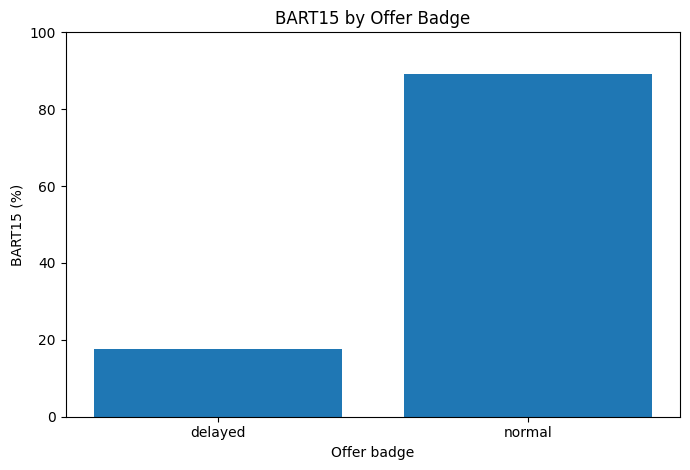

In [2]:
badge=main.dropna(subset=["order_offer_badge"]).groupby("order_offer_badge")["BART15"].mean().mul(100).reset_index()
fig, ax=plt.subplots(figsize=(7,4.8))
ax.bar(badge["order_offer_badge"],badge["BART15"])
ax.set_ylim(0,100)
ax.set_title("BART15 by Offer Badge")
ax.set_xlabel("Offer badge")
ax.set_ylabel("BART15 (%)")
savefig("F17_BART15_by_Offer_Badge.png")


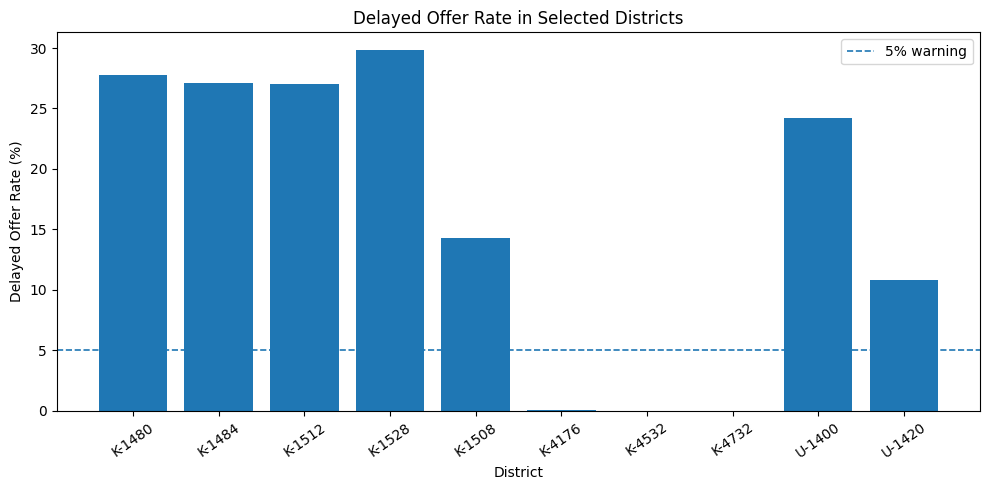

In [3]:
areas=["K-1480","K-1484","K-1512","K-1528","K-1508","K-4176","K-4532","K-4732","U-1400","U-1420"]
dor=main[main["city_district"].isin(areas)].groupby("city_district")["delayed_flag"].mean().mul(100).reindex(areas)
fig, ax=plt.subplots(figsize=(10,5))
ax.bar(dor.index,dor.values)
ax.axhline(5,linestyle="--",linewidth=1.2,label="5% warning")
ax.set_title("Delayed Offer Rate in Selected Districts")
ax.set_xlabel("District")
ax.set_ylabel("Delayed Offer Rate (%)")
ax.tick_params(axis="x",rotation=35)
ax.legend()
savefig("F18_Selected_District_Delayed_Offer_Rate.png")


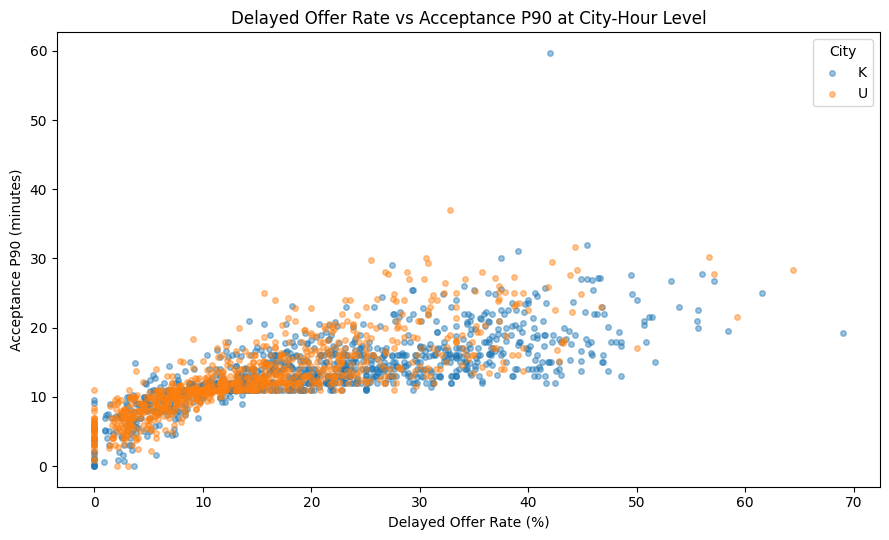

In [4]:
cityhour_main=main.groupby(["order_city","hour_bucket"]).agg(Orders=("order_id","size"),DOR=("delayed_flag","mean")).reset_index()
cityhour_seq=seq.groupby(["order_city","hour_bucket"]).agg(Acceptance_P90=("Acceptance_min",lambda s:s.quantile(.9)),Arrival_P90=("Arrival_min",lambda s:s.quantile(.9)),Seq_Orders=("order_id","size")).reset_index()
ch=cityhour_main.merge(cityhour_seq,on=["order_city","hour_bucket"])
ch=ch[(ch["Orders"]>=20)&(ch["Seq_Orders"]>=20)&ch["order_city"].isin(["K","U"])]
fig, ax=plt.subplots(figsize=(9,5.5))
for city_name,g in ch.groupby("order_city"):
    ax.scatter(g["DOR"]*100,g["Acceptance_P90"],s=16,alpha=.45,label=city_name)
ax.set_title("Delayed Offer Rate vs Acceptance P90 at City-Hour Level")
ax.set_xlabel("Delayed Offer Rate (%)")
ax.set_ylabel("Acceptance P90 (minutes)")
ax.legend(title="City")
savefig("F19_Delayed_Rate_vs_Acceptance_P90.png")


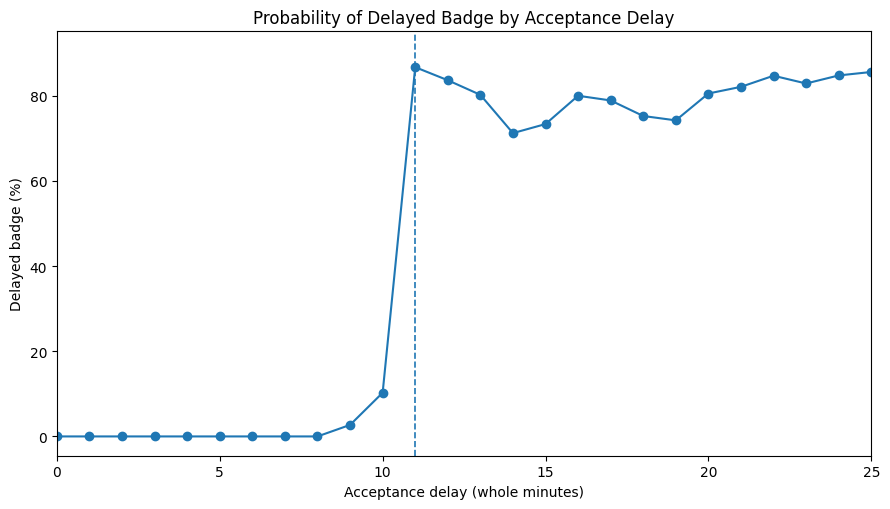

In [5]:
r=main[main["Acceptance_raw_min"].between(0,30)&main["delayed_flag"].notna()].copy()
r["accept_minute"]=np.floor(r["Acceptance_raw_min"]).astype(int)
by=r.groupby("accept_minute").agg(Delayed_Rate=("delayed_flag","mean"),Orders=("order_id","size")).reset_index()
fig, ax=plt.subplots(figsize=(9,5.2))
ax.plot(by["accept_minute"],by["Delayed_Rate"]*100,marker="o")
ax.axvline(11,linestyle="--",linewidth=1.2)
ax.set_xlim(0,25)
ax.set_title("Probability of Delayed Badge by Acceptance Delay")
ax.set_xlabel("Acceptance delay (whole minutes)")
ax.set_ylabel("Delayed badge (%)")
savefig("F20_Badge_Assignment_by_Acceptance_Minute.png")


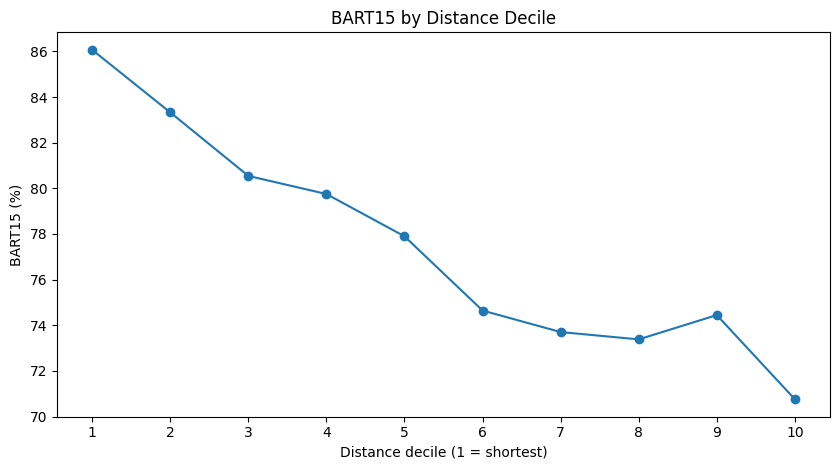

In [6]:
q=main.copy()
q["Distance_Decile"]=pd.qcut(q["distance_km"],10,labels=False,duplicates="drop")+1
x=q.groupby("Distance_Decile")["BART15"].mean().mul(100)
fig, ax=plt.subplots(figsize=(8.5,4.8))
ax.plot(x.index,x.values,marker="o")
ax.set_xticks(range(1,11))
ax.set_title("BART15 by Distance Decile")
ax.set_xlabel("Distance decile (1 = shortest)")
ax.set_ylabel("BART15 (%)")
savefig("F21_Distance_Decile_BART15.png")


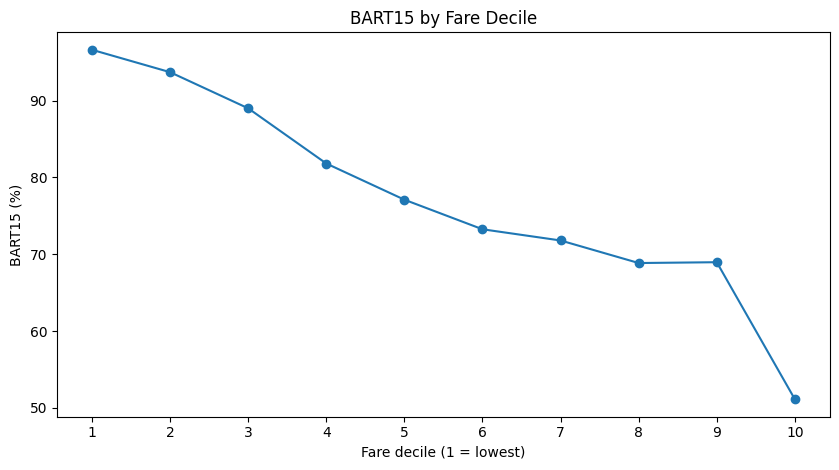

In [7]:
q["Fare_Decile"]=pd.qcut(q["fare_m"],10,labels=False,duplicates="drop")+1
x=q.groupby("Fare_Decile")["BART15"].mean().mul(100)
fig, ax=plt.subplots(figsize=(8.5,4.8))
ax.plot(x.index,x.values,marker="o")
ax.set_xticks(range(1,11))
ax.set_title("BART15 by Fare Decile")
ax.set_xlabel("Fare decile (1 = lowest)")
ax.set_ylabel("BART15 (%)")
savefig("F22_Fare_Decile_BART15.png")


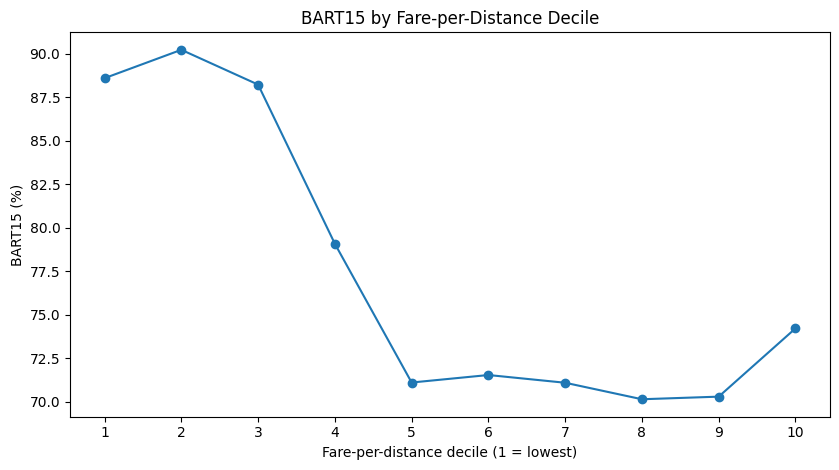

In [8]:
q2=q.replace([np.inf,-np.inf],np.nan).dropna(subset=["fare_per_km"]).copy()
q2["Fare_per_Distance_Decile"]=pd.qcut(q2["fare_per_km"],10,labels=False,duplicates="drop")+1
x=q2.groupby("Fare_per_Distance_Decile")["BART15"].mean().mul(100)
fig, ax=plt.subplots(figsize=(8.5,4.8))
ax.plot(x.index,x.values,marker="o")
ax.set_xticks(range(1,11))
ax.set_title("BART15 by Fare-per-Distance Decile")
ax.set_xlabel("Fare-per-distance decile (1 = lowest)")
ax.set_ylabel("BART15 (%)")
savefig("F23_Fare_Per_Distance_Decile_BART15.png")


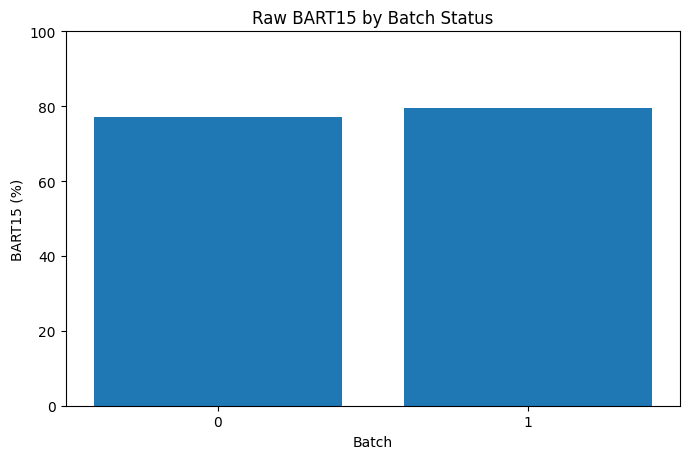

In [9]:
raw=main.groupby("batch")["BART15"].mean().mul(100)
fig, ax=plt.subplots(figsize=(7,4.7))
ax.bar(raw.index.astype(str),raw.values)
ax.set_ylim(0,100)
ax.set_title("Raw BART15 by Batch Status")
ax.set_xlabel("Batch")
ax.set_ylabel("BART15 (%)")
savefig("F24_Batch_Raw_BART15.png")


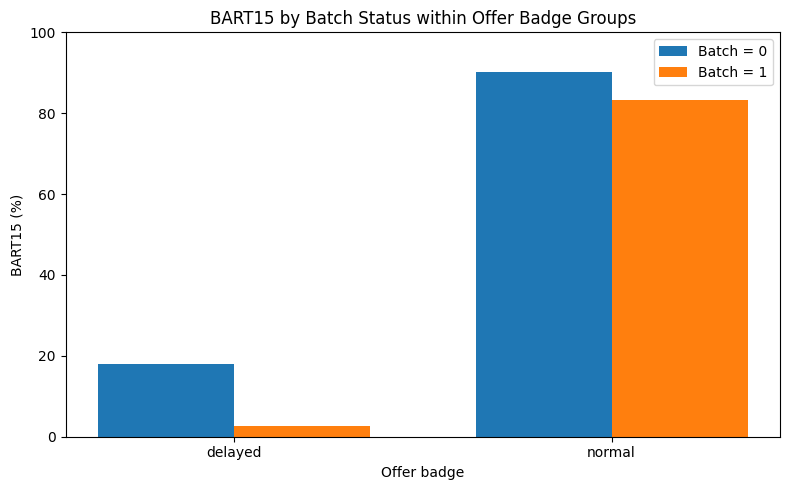

In [10]:
cond=main.dropna(subset=["delayed_flag"]).groupby(["order_offer_badge","batch"])["BART15"].mean().mul(100).unstack("batch")
fig, ax=plt.subplots(figsize=(8,5))
x=np.arange(len(cond.index)); w=.36
ax.bar(x-w/2,cond.get(0),w,label="Batch = 0")
ax.bar(x+w/2,cond.get(1),w,label="Batch = 1")
ax.set_xticks(x,labels=cond.index)
ax.set_ylim(0,100)
ax.set_title("BART15 by Batch Status within Offer Badge Groups")
ax.set_xlabel("Offer badge")
ax.set_ylabel("BART15 (%)")
ax.legend()
savefig("F25_Batch_Conditioned_by_Badge.png")


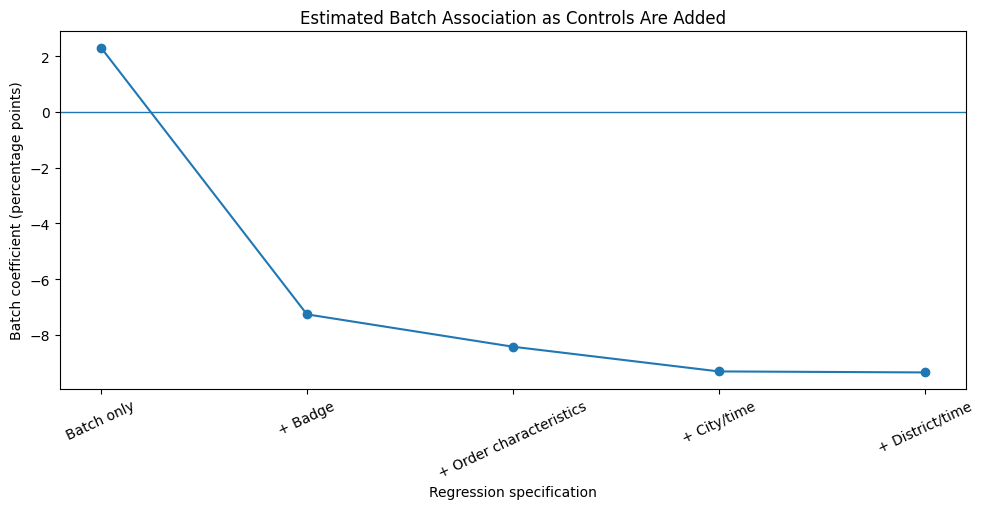

In [11]:
import statsmodels.formula.api as smf
reg=main.dropna(subset=["batch","delayed_flag","distance_km","fare_m","hour","weekday","month_num","district"]).copy()
specs={"Batch only":"BART15 ~ batch","+ Badge":"BART15 ~ batch + delayed_flag","+ Order characteristics":"BART15 ~ batch + delayed_flag + distance_km + fare_m","+ City/time":"BART15 ~ batch + delayed_flag + distance_km + fare_m + C(order_city) + C(hour) + C(weekday) + C(month_num)","+ District/time":"BART15 ~ batch + delayed_flag + distance_km + fare_m + C(district) + C(hour) + C(weekday) + C(month_num)"}
rows=[]
for name,formula in specs.items():
    m=smf.ols(formula,data=reg).fit(cov_type="HC1")
    rows.append({"Specification":name,"Batch_coefficient_pp":m.params["batch"]*100,"Robust_SE_pp":m.bse["batch"]*100,"R_squared":m.rsquared})
coef=pd.DataFrame(rows)
fig, ax=plt.subplots(figsize=(10,5.2))
ax.plot(coef["Specification"],coef["Batch_coefficient_pp"],marker="o")
ax.axhline(0,linewidth=1)
ax.set_title("Estimated Batch Association as Controls Are Added")
ax.set_xlabel("Regression specification")
ax.set_ylabel("Batch coefficient (percentage points)")
ax.tick_params(axis="x",rotation=25)
savefig("F26_Batch_Regression_Coefficient_Path.png")


In [12]:
reg["distance_q5"]=pd.qcut(reg["distance_km"],5,labels=False,duplicates="drop")
reg["fare_q5"]=pd.qcut(reg["fare_m"],5,labels=False,duplicates="drop")
matched=reg.groupby(["order_city","hour","delayed_flag","distance_q5","fare_q5","batch"])["BART15"].agg(["mean","count"]).reset_index()
piv=matched.pivot_table(index=["order_city","hour","delayed_flag","distance_q5","fare_q5"],columns="batch",values=["mean","count"]).dropna()
piv["diff"]=piv[("mean",1)]-piv[("mean",0)]
piv["weight"]=np.minimum(piv[("count",1)],piv[("count",0)])
summary=[{"Scope":"All cities","Matched strata":len(piv),"Batch minus Non-Batch BART15 (pp)":np.average(piv["diff"],weights=piv["weight"])*100}]
for city_name in ["B","K","U"]:
    z=piv.reset_index(); z=z[z["order_city"]==city_name]
    summary.append({"Scope":f"City {city_name}","Matched strata":len(z),"Batch minus Non-Batch BART15 (pp)":np.average(z["diff"],weights=z["weight"])*100})
match_table=pd.DataFrame(summary)
save_table(match_table,"T07_Batch_Matching_Summary.png")


,Scope,Matched strata,Batch minus Non-Batch BART15 (pp)
0,All cities,883,-8.21
1,City B,125,-3.11
2,City K,379,-9.17
3,City U,379,-7.86


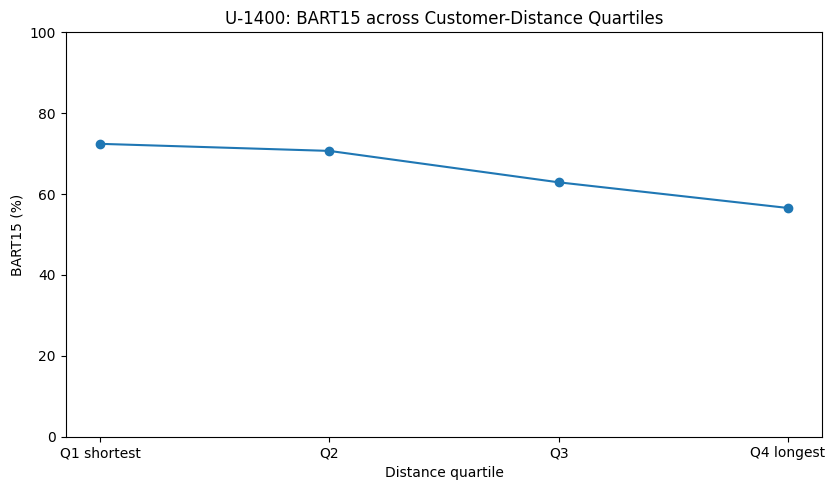

,Distance Quartile,Orders,BART15 (%),Acceptance Median (min),Acceptance P90 (min)
0,Q1 shortest,914,72.43,3.0,18.0
1,Q2,914,70.68,3.0,20.0
2,Q3,914,62.91,4.0,21.0
3,Q4 longest,914,56.56,8.0,23.7


In [13]:
u=seq[seq["city_district"]=="U-1400"].copy()
u["Distance_Quartile"]=pd.qcut(u["distance_km"],4,labels=["Q1 shortest","Q2","Q3","Q4 longest"])
uq=u.groupby("Distance_Quartile",observed=True).agg(Orders=("order_id","size"),BART15=("BART15","mean"),Acceptance_Median=("Acceptance_min","median"),Acceptance_P90=("Acceptance_min",lambda s:s.quantile(.9))).reset_index()
fig, ax=plt.subplots(figsize=(8.5,5))
ax.plot(uq["Distance_Quartile"].astype(str),uq["BART15"]*100,marker="o",label="BART15")
ax.set_ylim(0,100)
ax.set_title("U-1400: BART15 across Customer-Distance Quartiles")
ax.set_xlabel("Distance quartile")
ax.set_ylabel("BART15 (%)")
savefig("F27_U1400_Distance_Quartile_BART15.png")
uqt=uq.assign(BART15=lambda z:z["BART15"]*100).rename(columns={"Distance_Quartile":"Distance Quartile","BART15":"BART15 (%)","Acceptance_Median":"Acceptance Median (min)","Acceptance_P90":"Acceptance P90 (min)"})
save_table(uqt,"T08_U1400_Distance_Quartile_Diagnostics.png")
